In [20]:
dataset_folder = '/mnt/Data1/Nick/transcription_pipeline/'
# dataset_folder = 'mnt/Data1/Hugo/transcription_pipeline/'
# embryo_datasets = {
#     # 25C embryos Var2, 0.173 um/pixel
#     '001': [
#         'test_data/NSPARC/2025-03-31/MCP-mSG_His-RFP_Var2(001)_embryo01',
#         'test_data/NSPARC/2025-03-31/MCP-mSG_His-RFP_Var2(001)_embryo02',
#         'test_data/NSPARC/2025-04-01/MCP-mSG_His-RFP_Var2(001)_embryo20',
#         'test_data/NSPARC/2025-04-01/MCP-mSG_His-RFP_Var2(001)_embryo38',
#         'test_data/NSPARC/2025-04-14/MCP-mSG_His-RFP_Var2(001)_embryo28',
#         'test_data/NSPARC/2025-04-15/MCP-mSG_His-RFP_Var2(001)_embryo01',
#     ],
#
#     # 22C embryos PWM, 0.173 um/pixel
#     '003': [
#         'test_data/NSPARC/2025-04-29/MCP-mSG_His-RFP_RBSPWM(003)_embryo01',
#         'test_data/NSPARC/2025-04-29/MCP-mSG_His-RFP_RBSPWM(003)_embryo02',
#         'test_data/NSPARC/2025-04-29/MCP-mSG_His-RFP_RBSPWM(003)_embryo03',
#         'test_data/NSPARC/2025-05-06/MCP-mSG_His-RFP_RBSPWM(003)_embryo01_22C',
#         'test_data/NSPARC/2025-05-09/MCP-mSG_His-RFP_PWM(003)_embryo01',
#     ],
# }

# embryo_datasets = {
#     # 22C embryos Var2, 0.230 um/pixel
#     '001': [
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo01',
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo02',
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo03',
#         'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo04',
#     ],
#
#     # 22C embryos PWM, 0.230 um/pixel
#     '003': [
#         'test_data/NSPARC/2025-05-27/MCP-mSG_His-RFP_RBS(003)_embryo02',
#         'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo01',
#         'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo02',
#     ],
# }

# # Hugo's analysis
# embryo_datasets={
#     # 22C embryos PWM, 0.230 um/pixel, 8% 488 laser power
#     '003': [
#         'test_data/NSPARC/2025-07-17/MCP-mSG_His-RFP_RBS(003)(homo)_embryo01',
#         'test_data/NSPARC/2025-07-17/MCP-mSG_His-RFP_RBS(003)(homo)_embryo02',
#         'test_data/NSPARC/2025-07-17/MCP-mSG_His-RFP_RBS(003)(homo)_embryo03',
#         'test_data/NSPARC/2025-07-17/MCP-mSG_His-RFP_RBS(003)(homo)_embryo04',
#     ]
# }

# 2025-07-18
embryo_datasets={
    '003': [
        'test_data/NSPARC/2025-07-18/MCP-mSG_His-RFP_RBS(003)(homo)_embryo02',
    ]
}


 ######### Processing group: 003 #########
Dataset Path: /mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-07-18/MCP-mSG_His-RFP_RBS(003)(homo)_embryo02


<Figure size 640x480 with 0 Axes>

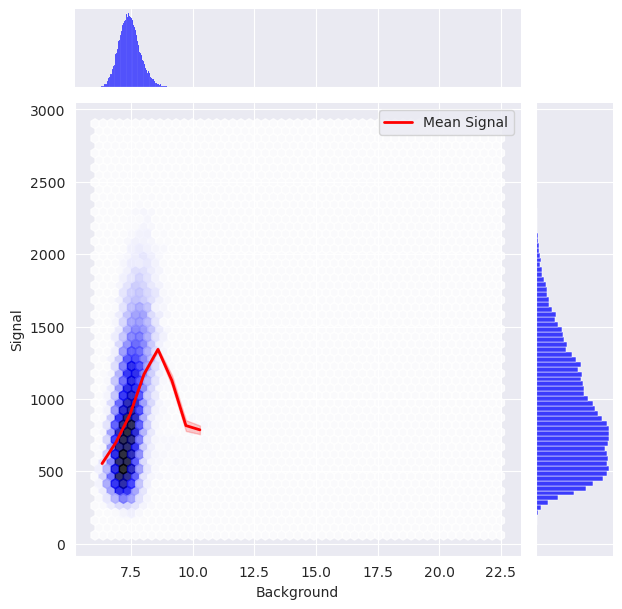

In [23]:
import os
from transcription_pipeline.RateExtraction import FitAndAverage
from transcription_pipeline import spot_pipeline
# from transcription_pipeline import nuclear_pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

# Parameters
nc14_start_frame = 0
min_frames = 40
num_bins = 40

# # Create output directory
# plot_output_dir = os.path.join(dataset_folder, 'signal_vs_background_plots')
# os.makedirs(plot_output_dir, exist_ok=True)

results = []

for group_name, embryo_list in embryo_datasets.items():
    print(f" ######### Processing group: {group_name} #########")
    # group_output_dir = os.path.join(plot_output_dir, group_name)
    # os.makedirs(group_output_dir, exist_ok=True)

    for embryo_id in embryo_list:
        test_dataset_name = os.path.join(dataset_folder, embryo_id)
        print('Dataset Path: ' + test_dataset_name)

        # --- Signal vs Background Analysis ---
        spot_tracking = spot_pipeline.Spot()
        spot_tracking.read_results(name_folder=test_dataset_name)

        spot_df = spot_tracking.spot_dataframe
        detected_spots = spot_df[spot_df["particle"] != 0]

        signal = np.array(detected_spots['intensity_from_neighborhood'])
        background = np.array(detected_spots['background_intensity_from_neighborhood'])

        # Plot signal vs background
        plt.figure()
        g = sns.jointplot(x=background, y=signal, kind='hex', color='blue', alpha=0.8)
        # plt.xlim(left=0, right=2.6)

        # Bin the background and compute mean signal and standard error
        bins = np.linspace(np.min(background), np.max(background), 30)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        digitized = np.digitize(background, bins)

        min_points = 50
        mean_signal = []
        std_signal = []
        valid_centers = []

        for i in range(1, len(bins)):
            bin_points = signal[digitized == i]
            if len(bin_points) >= min_points:
                mean_signal.append(np.mean(bin_points))
                std_signal.append(np.std(bin_points) / np.sqrt(len(bin_points)))
                valid_centers.append(bin_centers[i - 1])

        g.ax_joint.plot(valid_centers, mean_signal, 'r-', linewidth=2, label='Mean Signal')
        g.ax_joint.fill_between(valid_centers,
                                np.array(mean_signal) - np.array(std_signal),
                                np.array(mean_signal) + np.array(std_signal),
                                color='red', alpha=0.2)
        g.ax_joint.legend()

        plt.xlabel('Background')
        plt.ylabel('Signal')

        # Save plot
        embryo_name = os.path.basename(embryo_id)
        plot_filename = os.path.join(test_dataset_name, f'signal_vs_background.png')
        plt.savefig(plot_filename)
        plt.show()
        plt.close()

        # # --- RNAP Loading Rate Analysis ---
        # dataframe_path = os.path.join(test_dataset_name, 'compiled_dataframe.pkl')
        # if not os.path.exists(dataframe_path):
        #     print(f"Missing dataframe: {dataframe_path}, skipping.")
        #     continue
        #
        # compiled_dataframe = pd.read_pickle(dataframe_path)
        #
        # fit_and_average = FitAndAverage(
        #     compiled_dataframe, nc14_start_frame, min_frames, num_bins, test_dataset_name
        # )
        # x, y, y_err, _, _ = fit_and_average.average_particle_fits()
        #
        # results.append({
        #     'group': group_name,
        #     'embryo_id': embryo_id,
        #     'avg_bkg': np.mean(background),
        #     'avg_signal': np.mean(signal),
        #     'max_signal':np.max(signal),
        #     'x': x,
        #     'y': y,
        #     'y_err': y_err
        # })

# Convert results to DataFrame
average_fit_df = pd.DataFrame(results)


In [17]:
spot_tracking = spot_pipeline.Spot()
spot_tracking.read_results(name_folder=test_dataset_name)
print(test_dataset_name)
spot_df = spot_tracking.spot_dataframe

/mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-07-18/MCP-mSG_His-RFP_RBS(003)(homo)_embryo03


/mnt/Data1/Nick/transcription_pipeline/transcription_pipeline/spot_pipeline.py:1241: UserWarning: `spot_dataframe` not found, keeping as `None`.
  warnings.warn("`spot_dataframe` not found, keeping as `None`.")


In [19]:
spot_dataframe_path =  os.path.join(test_dataset_name, 'spot_analysis_results/spot_dataframe.pkl')
test_load_spotDataframe = pd.read_pickle(spot_dataframe_path)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-07-18/MCP-mSG_His-RFP_RBS(003)(homo)_embryo03/spot_analysis_results/spot_dataframe.pkl'

In [18]:
spot_df.head()

AttributeError: 'NoneType' object has no attribute 'head'

In [4]:
average_fit_df

,group,embryo_id,avg_bkg,avg_signal,x,y,y_err
0,001,test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RB...,0.813942,223.561722,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, nan, nan, nan, nan, 104.67006273127...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 47.210086847851..."
1,001,test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RB...,0.277066,149.411043,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, 42.80975072029966, 69.8135310876833...","[0.0, 0.0, 5.42053637115601, 8.681898877922828..."
2,001,test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RB...,0.645173,212.048704,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, nan, nan, 77.11244304031419, 100.38...","[0.0, 0.0, 0.0, 0.0, 11.766195695029095, 15.80..."
3,001,test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RB...,1.210909,190.612693,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, nan, 130.99926820137856, 122.466079...","[0.0, 0.0, 0.0, 31.204129004944203, 12.3712332..."
4,003,test_data/NSPARC/2025-05-27/MCP-mSG_His-RFP_RB...,0.906725,243.521588,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, 95.97005446831743, 110.254620688302...","[0.0, 0.0, 0.0, 16.265019177812487, 16.9941670..."
5,003,test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RB...,0.320013,164.895047,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, nan, 58.1850852677554, 71.984355080...","[0.0, 0.0, 0.0, 15.254049618221678, 11.0458153..."
6,003,test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RB...,0.415039,141.277890,"[0.0125, 0.037500000000000006, 0.0625, 0.08750...","[nan, nan, nan, nan, nan, 50.69805241603492, 7...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.995726827770..."


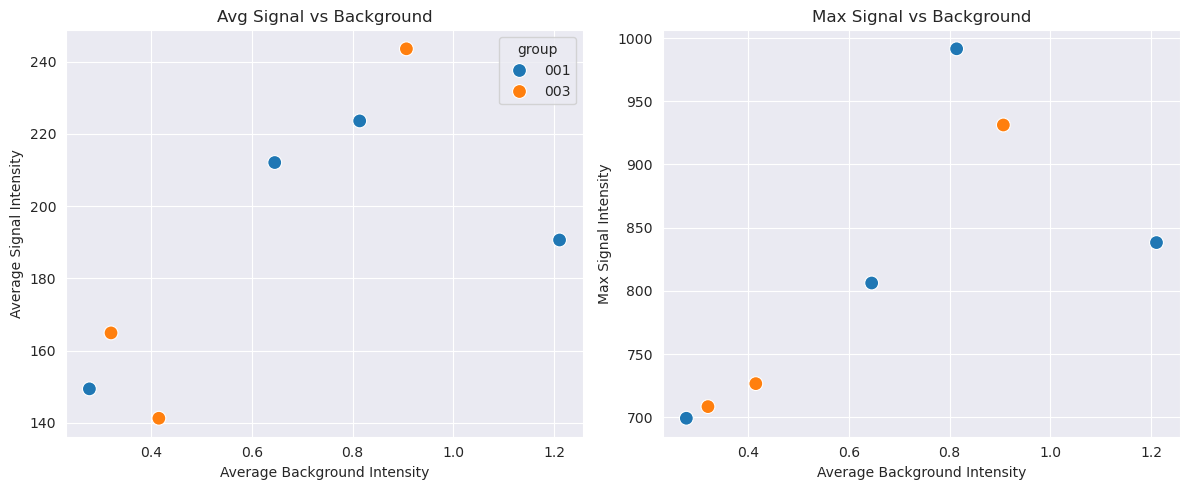

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: avg_signal vs avg_bkg
sns.scatterplot(
    data=average_fit_df,
    x='avg_bkg',
    y='avg_signal',
    hue='group',
    s=100,
    ax=axes[0]
)
axes[0].set_xlabel('Average Background Intensity')
axes[0].set_ylabel('Average Signal Intensity')
axes[0].set_title('Avg Signal vs Background')
axes[0].grid(True)

# Second subplot: max_signal vs avg_bkg
sns.scatterplot(
    data=average_fit_df,
    x='avg_bkg',
    y='max_signal',
    hue='group',
    s=100,
    ax=axes[1],
    legend=False  # avoid duplicate legend
)
axes[1].set_xlabel('Average Background Intensity')
axes[1].set_ylabel('Max Signal Intensity')
axes[1].set_title('Max Signal vs Background')
axes[1].grid(True)

plt.tight_layout()
plt.show()


001: Mean rate in AP range (0.15, 0.4) = 108.146 AU


/tmp/ipykernel_2509910/1631517691.py:47: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(vals)


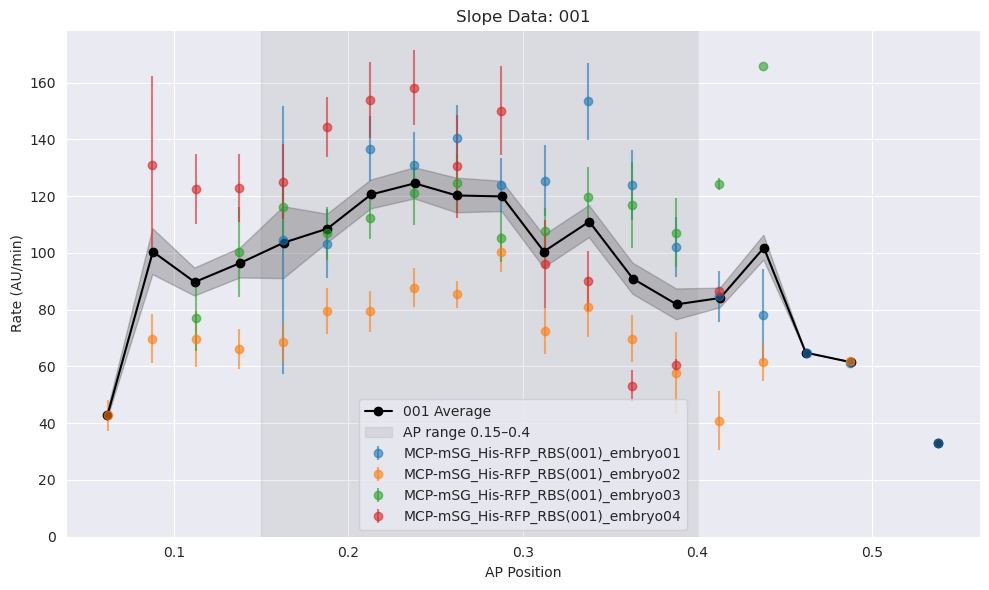

003: Mean rate in AP range (0.15, 0.4) = 99.179 AU


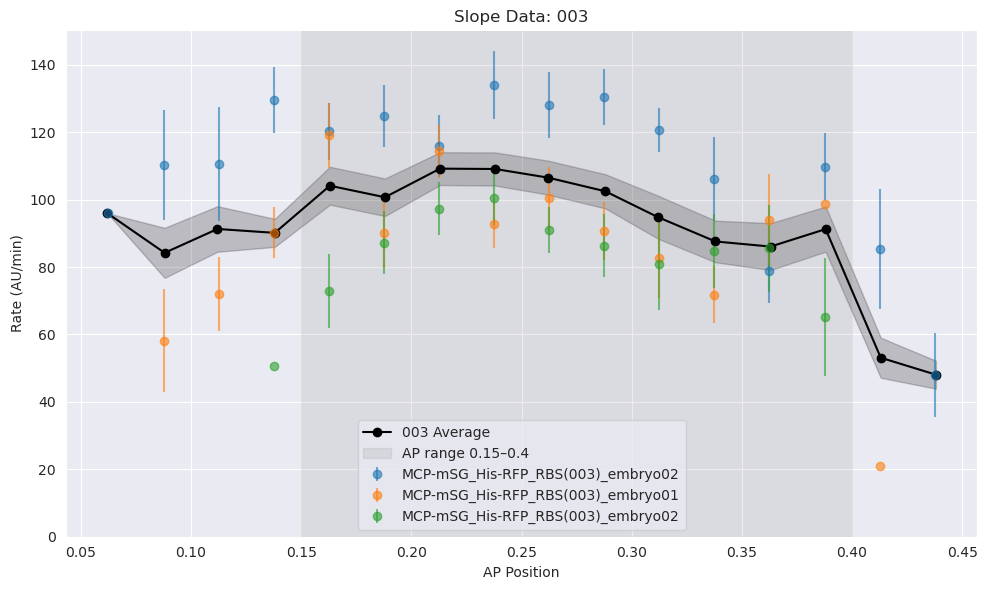

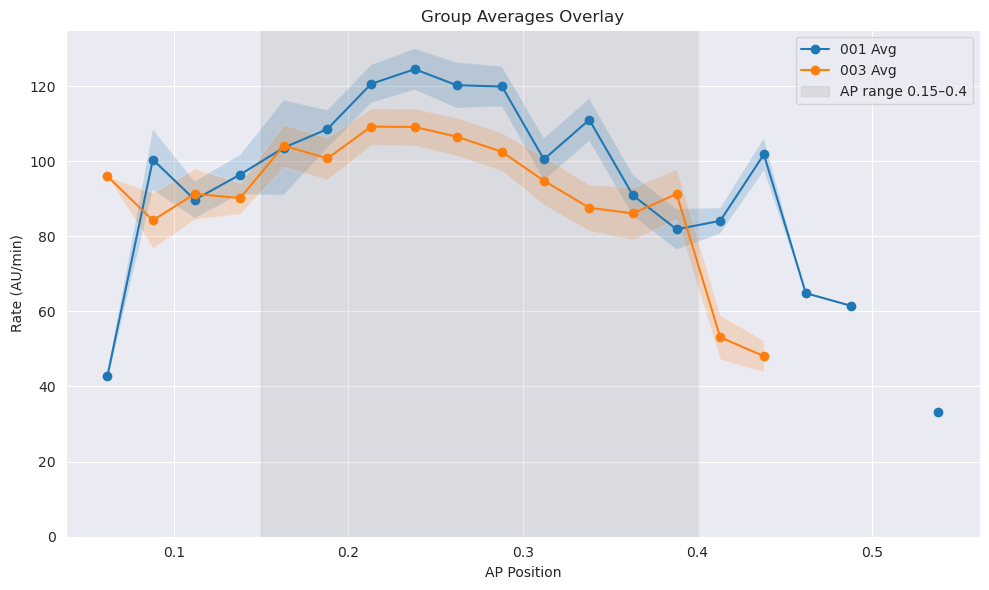

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Define the AP range of interest
ap_range = (0.15, 0.4)

# Create a dictionary to group embryos by group
grouped = average_fit_df.groupby('group')

group_averages = {}

for group_name, group_df in grouped:
    plt.figure(figsize=(10, 6))
    all_x, all_y, all_yerr = [], [], []

    for _, row in group_df.iterrows():
        x = np.array(row['x'])
        y = np.array(row['y'])
        y_err = np.array(row['y_err'])

        plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.6, label=os.path.basename(row['embryo_id']))
        all_x.append(x)
        all_y.append(y)
        all_yerr.append(y_err)

    # Combine data by AP bin
    bin_dict = {}
    err_dict = {}

    for x_vals, y_vals, yerr_vals in zip(all_x, all_y, all_yerr):
        for xi, yi, yerri in zip(x_vals, y_vals, yerr_vals):
            xi_rounded = np.round(xi, 3)
            bin_dict.setdefault(xi_rounded, []).append(yi)
            err_dict.setdefault(xi_rounded, []).append(yerri)

    avg_bins = sorted(bin_dict.keys())

    # Mean and standard error propagation
    avg_rates = []
    avg_errors = []
    for b in avg_bins:
        vals = np.array(bin_dict[b])
        errs = np.array(err_dict[b])
        n = len(vals)
        mean = np.nanmean(vals)
        se = np.sqrt(np.nansum(errs ** 2)) / n  # Error propagation
        avg_rates.append(mean)
        avg_errors.append(se)

    group_averages[group_name] = (avg_bins, avg_rates, avg_errors)

    # Plot group average
    plt.plot(avg_bins, avg_rates, '-o', color='black', label=f'{group_name} Average')
    plt.fill_between(avg_bins,
                     np.array(avg_rates) - np.array(avg_errors),
                     np.array(avg_rates) + np.array(avg_errors),
                     color='black', alpha=0.2)

    # Highlight AP range of interest
    plt.axvspan(ap_range[0], ap_range[1], color='gray', alpha=0.15, label='AP range 0.15–0.4')

    # Compute and display mean over AP range
    ap_vals = np.array(avg_bins)
    rate_vals = np.array(avg_rates)
    range_mask = (ap_vals >= ap_range[0]) & (ap_vals <= ap_range[1])
    mean_in_range = np.nanmean(rate_vals[range_mask])
    print(f'{group_name}: Mean rate in AP range {ap_range} = {mean_in_range:.3f} AU')

    # Plot formatting
    plt.title(f'Slope Data: {group_name}')
    plt.xlabel('AP Position')
    plt.ylabel('Rate (AU/min)')
    plt.ylim(bottom=0)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Combined group averages ---
plt.figure(figsize=(10, 6))

for group_name, (avg_bins, avg_rates, avg_errors) in group_averages.items():
    plt.plot(avg_bins, avg_rates, '-o', label=f'{group_name} Avg')
    plt.fill_between(avg_bins,
                     np.array(avg_rates) - np.array(avg_errors),
                     np.array(avg_rates) + np.array(avg_errors),
                     alpha=0.2)

# Highlight AP range
plt.axvspan(ap_range[0], ap_range[1], color='gray', alpha=0.15, label='AP range 0.15–0.4')

plt.title('Group Averages Overlay')
plt.xlabel('AP Position')
plt.ylabel('Rate (AU/min)')
plt.legend()
plt.ylim(bottom=0)
plt.grid(True)
plt.tight_layout()
plt.show()
